# Treinamento do modelo FinBERT com o dataset

**Autores:**  
Bruno E A Hayek - RA: 10389776    
Xuan Zhu - RA: 10401714

In [1]:
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from src.headline_forecast import *
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
twitter_dados = pd.read_pickle("pkls/twitter_dados.pkl")

In [2]:

input_ids      = torch.cat([t["input_ids"]      for t in twitter_dados["tokenized"]], dim=0)
attention_mask = torch.cat([t["attention_mask"] for t in twitter_dados["tokenized"]], dim=0)
labels = torch.tensor(twitter_dados["label"].tolist())

dataset = TensorDataset(input_ids, attention_mask, labels)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

train_ids, test_ids = train_test_split(
    list(range(len(labels))),
    test_size=0.2,
    random_state=42,
    stratify=labels 
)

train_ds = TensorDataset(
    input_ids[train_ids],
    attention_mask[train_ids],
    labels[train_ids]
)
test_ds = TensorDataset(
    input_ids[test_ids],
    attention_mask[test_ids],
    labels[test_ids]
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

Criando o modelo

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert", num_labels=3
).to(device)

optimizer = Adam(
    model.parameters(), 
    lr=2e-5,            # typical for BERT fine-tuning
    weight_decay=0.01   # regularization
)

2025-05-30 15:15:07.503489: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Treinando o modelo

In [4]:

num_epoch = 5

for epoch in range(num_epoch):
    model.train()
    for batch in dataloader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Época {epoch} completa.")

model.save_pretrained("finbert_finetuned")
tokenizer.save_pretrained("finbert_finetuned")

Época 0 completa.
Época 1 completa.
Época 2 completa.
Época 3 completa.
Época 4 completa.


('finbert_finetuned/tokenizer_config.json',
 'finbert_finetuned/special_tokens_map.json',
 'finbert_finetuned/vocab.txt',
 'finbert_finetuned/added_tokens.json',
 'finbert_finetuned/tokenizer.json')

Avaliando o modelo

Acurácia: 0.9240

Report:
              precision    recall  f1-score   support

     Bearish       0.97      0.70      0.81       288
     Bullish       0.82      0.96      0.88       385
     Neutral       0.95      0.97      0.96      1236

    accuracy                           0.92      1909
   macro avg       0.91      0.87      0.89      1909
weighted avg       0.93      0.92      0.92      1909



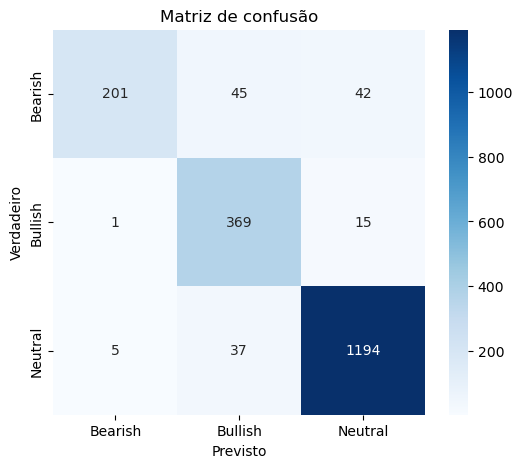

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=["Bearish","Bullish","Neutral"])
matriz_conf = confusion_matrix(all_labels, all_preds)

print(f"Acurácia: {acc:.4f}\n")
print("Report:")
print(report)

plot_matriz_conf(matriz_conf)



Salvando o modelo

In [6]:
model.save_pretrained("finbert_finetuned")
tokenizer.save_pretrained("finbert_finetuned")

('finbert_finetuned/tokenizer_config.json',
 'finbert_finetuned/special_tokens_map.json',
 'finbert_finetuned/vocab.txt',
 'finbert_finetuned/added_tokens.json',
 'finbert_finetuned/tokenizer.json')

# Previsão de headlines de notícias

In [ ]:
"""
Fonte das notícias

https://finance.yahoo.com/video/nasdaq-soars-over-4-leads-200631581.html
https://finance.yahoo.com/video/p-500-stocks-inch-higher-200804174.html
https://www.nasdaq.com/articles/looming-us-debt-ceiling-sparks-bitcoin-market-concerns
https://finance.yahoo.com/news/teslas-optimus-may-first-humanoid-114200172.html
https://finance.yahoo.com/news/cisco-systems-inc-csco-benefit-170445925.html
https://www.ig.com/uk/news-and-trade-ideas/Will-Nvidia-earnings-provide-relief-after-Wall-Streets-weekly-decline-250526
https://www.ig.com/uk/news-and-trade-ideas/us-weekly-report--wall-street-lifted-out-of-extreme-fear-zone-250429
https://www.fool.com/investing/2025/01/15/why-intel-stock-fell-60-in-2024/

"""

tokenizer = AutoTokenizer.from_pretrained("finbert_finetuned")
model = AutoModelForSequenceClassification.from_pretrained("finbert_finetuned")


news = [
    'Nasdaq soars over 4%, leads stock rally after US-China truce',
    'S&P 500, stocks inch higher after appeals court unpauses tariffs',
    'Looming U.S. Debt Ceiling Sparks Bitcoin Market Concerns ',
    'Teslas Optimus May Be The First Humanoid Robot To Achieve High Volume And Tech Scale, Says Nvidia CEO Jensen Huang: ... Likely To Be The Next Multi-Trillion Dollar Industry',
    'Cisco Systems, Inc. (CSCO) Can Benefit From The European Market, Says Jim Cramer',
    'US Weekly Report: Wall Street lifted out of “extreme fear” zone',
    'Will Nvidia earnings provide relief after Wall Streets weekly decline?',
    'Why Intel Stock Fell 60% in 2024'
    ]

prever_noticias(news, model, tokenizer)

Notícia: Nasdaq soars over 4%, leads stock rally after US-China truce → Previsão Bullish
Notícia: S&P 500, stocks inch higher after appeals court unpauses tariffs → Previsão Bullish
Notícia: Looming U.S. Debt Ceiling Sparks Bitcoin Market Concerns  → Previsão Bullish
Notícia: Teslas Optimus May Be The First Humanoid Robot To Achieve High Volume And Tech Scale, Says Nvidia CEO Jensen Huang: ... Likely To Be The Next Multi-Trillion Dollar Industry → Previsão Neutral
Notícia: Cisco Systems, Inc. (CSCO) Can Benefit From The European Market, Says Jim Cramer → Previsão Bullish
Notícia: US Weekly Report: Wall Street lifted out of “extreme fear” zone → Previsão Bullish
Notícia: Will Nvidia earnings provide relief after Wall Streets weekly decline? → Previsão Bullish
Notícia: Why Intel Stock Fell 60% in 2024 → Previsão Bearish
